In [2]:
# CELL 1 - SETUP
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten,
    BatchNormalization, Dropout, Activation,
    Rescaling, Input
)
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import classification_report

# Paths
train_dir = '/content/drive/MyDrive/AI and Machine Learning/FruitinAmazon/FruitinAmazon/train'
test_dir  = '/content/drive/MyDrive/AI and Machine Learning/FruitinAmazon/FruitinAmazon/test'

# Settings
IMG_HEIGHT = 224
IMG_WIDTH  = 224
BATCH_SIZE = 32
EPOCHS     = 100

print("Setup complete.")
print(f"TensorFlow version: {tf.__version__}")

Setup complete.
TensorFlow version: 2.19.0


Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


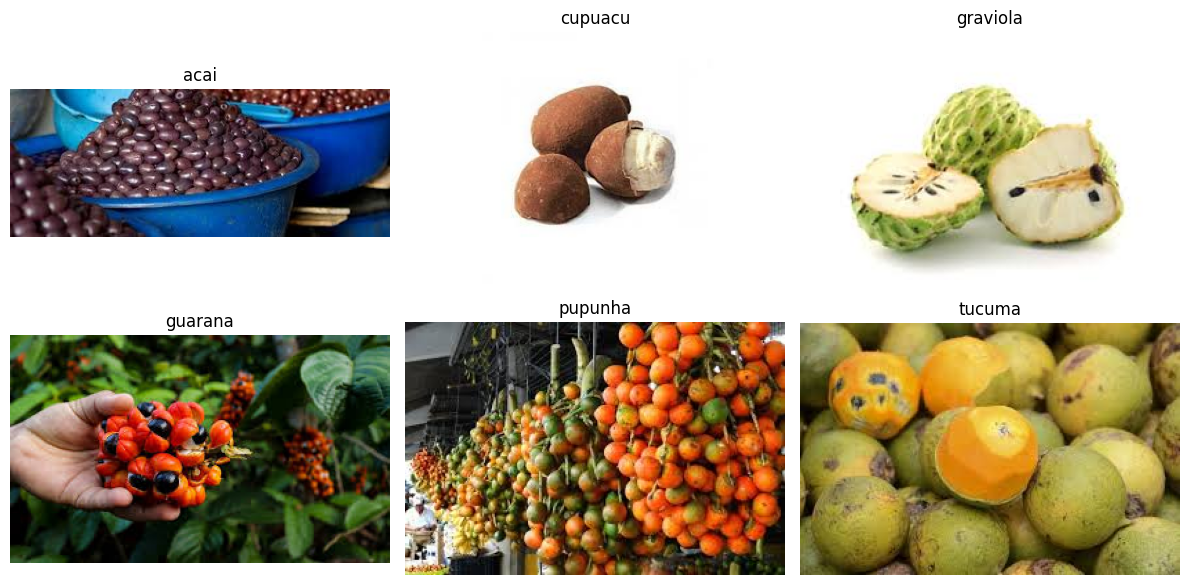

In [7]:
# TASK 1: VISUALIZE IMAGES

# Get class names from train folder
class_names = sorted(os.listdir(train_dir))
print(f"Found {len(class_names)} classes: {class_names}")

# Pick one random image from each class
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

# Display in a 2 row grid
num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# TASK 1: CHECK CORRUPTED IMAGES

corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)
                os.remove(img_path)
                print(f"Removed corrupted image: {img_path}")

if not corrupted_images:
    print("No corrupted images found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No corrupted images found.


In [10]:
# TASK 1: CLASS DISTRIBUTION

class_counts = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


In [11]:
#TASK 2: DATA LOADING + AUGMENTATION

# Load train and validation datasets
train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# Save class names
class_names = train_ds.class_names
print("Classes:", class_names)

# Check dataset shape
for images, labels in train_ds.take(1):
    print(f"Image batch shape: {images.shape}")
    print(f"Label batch shape: {labels.shape}")

# Data augmentation
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

# Performance optimisation
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("\nDatasets ready!")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)

Datasets ready!


In [12]:
#TASK 3: BUILD THE MODEL

num_classes = len(class_names)

model = Sequential([

    Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # Augmentation and normalisation
    data_augmentation,
    Rescaling(1./255),

    # Block 1
    Conv2D(32, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # Block 2
    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # Block 3
    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # Fully connected layers
    Flatten(),

    Dense(256),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.4),

    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.4),

    # Output
    Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,89

 Total params: 25,819,718 (98.49 MB)

 Trainable params: 25,818,502 (98.49 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [13]:
#TASK 4: COMPILE AND TRAIN

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/AI and Machine Learning/best_model_ws6.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=7,
    min_lr=0.00001,
    verbose=1
)

# Train
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stopping, reduce_lr]
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.1944 - loss: 2.4579
Epoch 1: val_accuracy improved from None to 0.16667, saving model to /content/drive/MyDrive/AI and Machine Learning/best_model_ws6.h5



Epoch 1: finished saving model to /content/drive/MyDrive/AI and Machine Learning/best_model_ws6.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 30s 8s/step - accuracy: 0.2083 - loss: 2.4282 - val_accuracy: 0.1667 - val_loss: 2.4433 - learning_rate: 0.0010
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.4516 - loss: 1.6350
Epoch 2: val_accuracy did not improve from 0.16667
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 7s/step - accuracy: 0.4861 - loss: 1.4868 - val_accuracy: 0.0556 - val_loss: 1.9446 - learning_rate: 0.0010
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5519 - loss: 1.3089
Epoch 3: val_accuracy did not improve from 0.16667
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 8s/step - accuracy: 0.5556 - loss: 1.3133 - val_accuracy: 0.1111 - val_loss: 1.8414 - learning_rate: 0.0010
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5897 - loss: 1.0770
Epoch 4: val_accuracy improved from 0.16667 to 0.22222, saving model to /content/drive/MyDrive/AI and Machine Learning/best_model_ws6.h5



Epoch 4: finished saving model to /content/drive/MyDrive/AI and Machine Learning/best_model_ws6.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 7s/step - accuracy: 0.5972 - loss: 1.0595 - val_accuracy: 0.2222 - val_loss: 1.8792 - learning_rate: 0.0010
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5373 - loss: 1.1474
Epoch 5: val_accuracy did not improve from 0.22222
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.5556 - loss: 1.0928 - val_accuracy: 0.2222 - val_loss: 2.0399 - learning_rate: 0.0010
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6951 - loss: 0.9319
Epoch 6: val_accuracy did not improve from 0.22222
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.6667 - loss: 0.9753 - val_accuracy: 0.1667 - val_loss: 2.1431 - learning_rate: 0.0010
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7176 - loss: 0.7119
Epoch 7: val_accuracy did not improve from 0.22222
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 6s/step - accuracy: 0.6528 - loss: 0.8410 - val_accuracy: 0.2

Best model loaded successfully.
Model recompiled successfully.
Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.2667 - loss: 1.8641

Test Loss:     1.8641
Test Accuracy: 0.2667
Test Accuracy: 26.67%


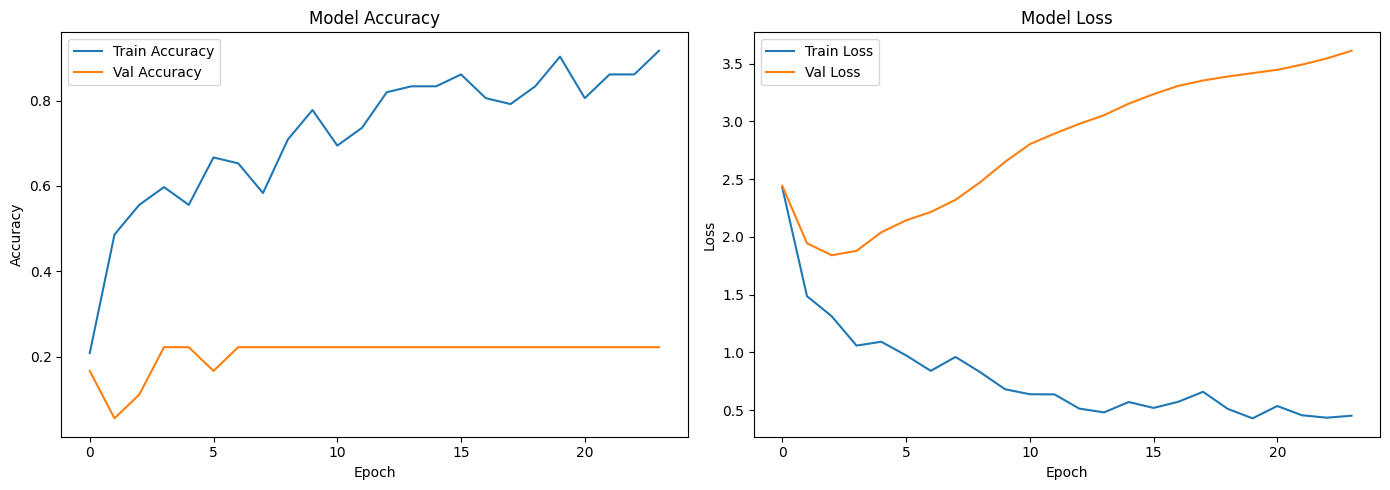

In [14]:
# TASK 5: EVALUATE THE MODEL

# Load best saved model
model = tf.keras.models.load_model(
    '/content/drive/MyDrive/AI and Machine Learning/best_model_ws6.h5'
)
print("Best model loaded successfully.")

# Recompile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model recompiled successfully.")

# Load test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Evaluate
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

In [18]:
#TASK 6: SAVE AND LOAD THE MODEL

save_path = '/content/drive/MyDrive/AI and Machine Learning/final_model_ws6.keras'

# Save the model
model.save(save_path)
print(f"Model saved to: {save_path}")

# Load it back
loaded_model = tf.keras.models.load_model(save_path)
print("Model loaded successfully.")

# Recompile
loaded_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Verify it works by evaluating again
test_loss, test_accuracy = loaded_model.evaluate(test_ds, verbose=1)
print(f"\nLoaded Model Test Accuracy: {test_accuracy * 100:.2f}%")

Model saved to: /content/drive/MyDrive/AI and Machine Learning/final_model_ws6.keras
Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2667 - loss: 1.8641

Loaded Model Test Accuracy: 26.67%


In [20]:
print(f"Trained for {len(history.history['val_accuracy'])} epochs")
print(f"Best val accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Best train accuracy: {max(history.history['accuracy']):.4f}")

Trained for 24 epochs
Best val accuracy: 0.2222
Best train accuracy: 0.9167


In [22]:
#TASK 7: PREDICTIONS AND CLASSIFICATION REPORT

all_true_labels = []
all_predictions = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    all_predictions.extend(np.argmax(preds, axis=1))
    all_true_labels.extend(labels.numpy())

print("Classification Report:")
print(classification_report(
    all_true_labels,
    all_predictions,
    target_names=test_ds.class_names
))

Classification Report:
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.17      0.80      0.29         5
    graviola       0.57      0.80      0.67         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.27        30
   macro avg       0.12      0.27      0.16        30
weighted avg       0.12      0.27      0.16        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
# CELL 11 - TASK 2 (WS6): VGG16 TRANSFER LEARNING

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Load VGG16 pre-trained on ImageNet, without the top classification layer
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Freeze all VGG16 layers - we don't want to change what it already knows
for layer in base_model.layers:
    layer.trainable = False

print(f"Total layers in VGG16: {len(base_model.layers)}")
print(f"Trainable layers: {sum(1 for l in base_model.layers if l.trainable)}")
print(f"Frozen layers: {sum(1 for l in base_model.layers if not l.trainable)}")

# Add our custom classification layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(num_classes, activation='softmax')(x)

# Create final model
vgg_model = Model(inputs=base_model.input, outputs=x)

# Compile
vgg_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total layers in VGG16: 19
Trainable layers: 0
Frozen layers: 19


Model: "functional_95"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 14,879,686 (56.76 MB)

 Trainable params: 164,998 (644.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [24]:
# CELL 12 - TRAIN VGG16

vgg_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/AI and Machine Learning/best_vgg16.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

vgg_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

vgg_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

vgg_history = vgg_model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[vgg_checkpoint, vgg_early_stopping, vgg_reduce_lr]
)

Epoch 1/100


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.1861 - loss: 9.3369 


Epoch 1: val_accuracy improved from None to 0.22222, saving model to /content/drive/MyDrive/AI and Machine Learning/best_vgg16.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI and Machine Learning/best_vgg16.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 55s 23s/step - accuracy: 0.2083 - loss: 9.7348 - val_accuracy: 0.2222 - val_loss: 3.7707 - learning_rate: 0.0010
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.2031 - loss: 6.1315 
Epoch 2: val_accuracy improved from 0.22222 to 0.44444, saving model to /content/drive/MyDrive/AI and Machine Learning/best_vgg16.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI and Machine Learning/best_vgg16.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 49s 16s/step - accuracy: 0.2500 - loss: 5.7310 - val_accuracy: 0.4444 - val_loss: 2.4060 - learning_rate: 0.0010
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.3189 - loss: 4.2849 
Epoch 3: val_accuracy improved from 0.44444 to 0.61111, saving model to /content/drive/M

In [25]:
# CELL 13 - EVALUATE VGG16

# Load best saved VGG16 model
vgg_model = tf.keras.models.load_model(
    '/content/drive/MyDrive/AI and Machine Learning/best_vgg16.keras'
)
print("Best VGG16 model loaded successfully.")

# Recompile
vgg_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Evaluate
test_loss, test_accuracy = vgg_model.evaluate(test_ds, verbose=1)
print(f"\nVGG16 Test Accuracy: {test_accuracy * 100:.2f}%")

Best VGG16 model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step - accuracy: 0.4667 - loss: 2.4860

VGG16 Test Accuracy: 46.67%


In [26]:
# CELL 15 - COMPARISON: SCRATCH vs VGG16

print("=" * 40)
print("MODEL COMPARISON")
print("=" * 40)
print(f"CNN from scratch:  26.67%")
print(f"VGG16 Transfer:    {test_accuracy * 100:.2f}%")
print("=" * 40)
print(f"Improvement: +{(test_accuracy * 100) - 26.67:.2f}%")

MODEL COMPARISON
CNN from scratch:  26.67%
VGG16 Transfer:    46.67%
Improvement: +20.00%
